### Predict Wine Quaity using AdaBoost Classifier

##### A Boosting based ML approach to classify high-quality wine from physicochemical properties


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE


In [8]:
df = pd.read_csv('Datasets/8_winequality-red.csv',sep = ';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [9]:
df['target'] = df['quality'].apply(lambda x:1 if x >= 7 else 0)

In [10]:
print("Before SMOTE:\n", df['target'].value_counts())

Before SMOTE:
 target
0    1382
1     217
Name: count, dtype: int64


In [11]:
X = df.drop(['quality', 'target'], axis = 1)
y = df['target']


In [12]:
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X,y)
print("\nAfter SMOTE:\n", y_balanced.value_counts())


After SMOTE:
 target
0    1382
1    1382
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size= 0.2, random_state= 42, stratify = y_balanced)


- Now, in Adaboost, we start with Initializing a Base Estimator (Weak Learner)
- We start with simple model - often called a "weak Learneer"
- We are using a decision stump ( a tree with max_deplth = 1) which makes simple yes/no splits.


In [24]:
base_estimator_model = DecisionTreeClassifier(max_depth = 1)
# to avoid overfitting max depth is one.

##### Initialize AdaBoost Classifier
- Adaboost works by combining several weak learners to create a strong classifier.

In [33]:
ada_model = AdaBoostClassifier(
    estimator = base_estimator_model,
    n_estimators= 50,
    learning_rate= 1.0,
    random_state = 42
)
# n_estimators = 50 - means we will train 50 weak learners sequentially.
# learning_rate controls how much each weak Learner contrigutes (degault is 1.0)
# Base_estimator is the simple model we defined above.

In [34]:
ada_model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [35]:
y_pred = ada_model.predict(X_test)

In [36]:
print("\n Classification Report: \n ", classification_report(y_test,y_pred))


 Classification Report: 
                precision    recall  f1-score   support

           0       0.84      0.86      0.85       277
           1       0.85      0.84      0.84       276

    accuracy                           0.85       553
   macro avg       0.85      0.85      0.85       553
weighted avg       0.85      0.85      0.85       553



In [37]:
accuracy_score(y_test,y_pred)

0.8462929475587704

<Axes: >

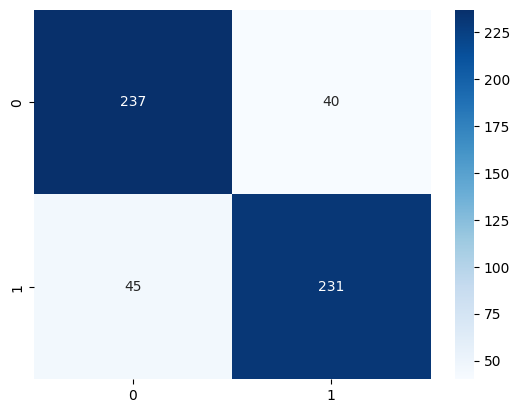

In [42]:
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',cmap='Blues', annot=True)

##### Observation 
Adaboost improves performance by focusing more on misclassified examples.

**It give better results particualarly for unbalanced data**